In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# cargar Dataset de ejemplo

simulamos ventas de una tienda con varias sucursales y producto, la base de datos se ha configurado en SQLite (local)

In [7]:
import sqlite3

conexion = sqlite3.connect("ejemploClasificacion.db")

query = "SELECT * FROM sqlite_master WHERE type='table';"

tablas = pd.read_sql(query, conexion)

print(tablas)

    type             name         tbl_name  rootpage  \
0  table  sqlite_sequence  sqlite_sequence         6   
1  table           ventas           ventas         2   
2  table        productos        productos         4   

                                                 sql  
0             CREATE TABLE sqlite_sequence(name,seq)  
1  CREATE TABLE "ventas" (\n\t"id_venta"\tINTEGER...  
2  CREATE TABLE "productos" (\n\t"id_producto"\tI...  


In [8]:
df1 = pd.read_sql("SELECT * FROM ventas", conexion)
df2 = pd.read_sql("SELECT * FROM productos", conexion)
df = pd.merge(df1, df2, on="id_producto", how="left")
df

,id_venta,fecha,id_producto,precio_unitario,cantidad,importe_total,sucursal,producto,precio,categoria
0,1,01-02-2026,1,120,1,120,este,zapatos,120,calzado
1,2,01-02-2026,1,120,1,120,sur,zapatos,120,calzado
2,3,03-03-2026,0,200,2,400,este,bolsa,200,damas
3,4,09-03-2026,7,450,2,900,este,locion,450,perfumeria
4,5,17-03-2026,6,720,2,1440,sur,reloj,720,joyeria
5,6,18-03-2026,6,720,1,720,norte,reloj,720,joyeria
6,7,22-03-2026,2,220,3,660,oeste,botas,220,calzado
7,8,22-03-2026,3,210,3,630,norte,vestido,210,damas
8,9,27-03-2026,8,390,1,390,oeste,perfume,390,perfumeria
9,10,28-03-2026,8,390,4,1560,sur,perfume,390,perfumeria


## Preguntas a responder

- ¿Que producto genera mas ingresos?
- ¿Que sucursal vende mas?
- ¿Que categoría es la mas rentable?
- ¿Que tendencias hay por mes?

## Preparación de datos

In [9]:
df

,id_venta,fecha,id_producto,precio_unitario,cantidad,importe_total,sucursal,producto,precio,categoria
0,1,01-02-2026,1,120,1,120,este,zapatos,120,calzado
1,2,01-02-2026,1,120,1,120,sur,zapatos,120,calzado
2,3,03-03-2026,0,200,2,400,este,bolsa,200,damas
3,4,09-03-2026,7,450,2,900,este,locion,450,perfumeria
4,5,17-03-2026,6,720,2,1440,sur,reloj,720,joyeria
5,6,18-03-2026,6,720,1,720,norte,reloj,720,joyeria
6,7,22-03-2026,2,220,3,660,oeste,botas,220,calzado
7,8,22-03-2026,3,210,3,630,norte,vestido,210,damas
8,9,27-03-2026,8,390,1,390,oeste,perfume,390,perfumeria
9,10,28-03-2026,8,390,4,1560,sur,perfume,390,perfumeria


In [10]:
# eliminar columna 'precio' 
df = df.drop(columns=['precio'])
df

,id_venta,fecha,id_producto,precio_unitario,cantidad,importe_total,sucursal,producto,categoria
0,1,01-02-2026,1,120,1,120,este,zapatos,calzado
1,2,01-02-2026,1,120,1,120,sur,zapatos,calzado
2,3,03-03-2026,0,200,2,400,este,bolsa,damas
3,4,09-03-2026,7,450,2,900,este,locion,perfumeria
4,5,17-03-2026,6,720,2,1440,sur,reloj,joyeria
5,6,18-03-2026,6,720,1,720,norte,reloj,joyeria
6,7,22-03-2026,2,220,3,660,oeste,botas,calzado
7,8,22-03-2026,3,210,3,630,norte,vestido,damas
8,9,27-03-2026,8,390,1,390,oeste,perfume,perfumeria
9,10,28-03-2026,8,390,4,1560,sur,perfume,perfumeria


In [11]:
# cambiar formato de fecha a datetime dd-mm-yyyy
df['fecha'] = pd.to_datetime(df['fecha'], format='%d-%m-%Y')
df['mes'] = df['fecha'].dt.month_name()
df

,id_venta,fecha,id_producto,precio_unitario,cantidad,importe_total,sucursal,producto,categoria,mes
0,1,2026-02-01,1,120,1,120,este,zapatos,calzado,February
1,2,2026-02-01,1,120,1,120,sur,zapatos,calzado,February
2,3,2026-03-03,0,200,2,400,este,bolsa,damas,March
3,4,2026-03-09,7,450,2,900,este,locion,perfumeria,March
4,5,2026-03-17,6,720,2,1440,sur,reloj,joyeria,March
5,6,2026-03-18,6,720,1,720,norte,reloj,joyeria,March
6,7,2026-03-22,2,220,3,660,oeste,botas,calzado,March
7,8,2026-03-22,3,210,3,630,norte,vestido,damas,March
8,9,2026-03-27,8,390,1,390,oeste,perfume,perfumeria,March
9,10,2026-03-28,8,390,4,1560,sur,perfume,perfumeria,March


## Datos limpios, estructurados y completos

In [12]:
print('tamaño del data set:', df.shape)
print('tipos de datos: ', df.dtypes)
print('\n ---resumen estadistico: \n', df.describe())

tamaño del data set: (40, 10)
tipos de datos:  id_venta                    int64
fecha              datetime64[ns]
id_producto                 int64
precio_unitario             int64
cantidad                    int64
importe_total               int64
sucursal                   object
producto                   object
categoria                  object
mes                        object
dtype: object

 ---resumen estadistico: 
         id_venta                fecha  id_producto  precio_unitario  \
count  40.000000                   40    40.000000        40.000000   
mean   20.500000  2026-04-26 07:12:00     5.425000       306.750000   
min     1.000000  2026-02-01 00:00:00     0.000000        80.000000   
25%    10.750000  2026-03-29 12:00:00     3.000000       210.000000   
50%    20.500000  2026-04-20 12:00:00     5.500000       230.000000   
75%    30.250000  2026-06-06 06:00:00     8.000000       390.000000   
max    40.000000  2026-06-30 00:00:00    10.000000       720.000000   
std

In [13]:
print('resumen de ventas totales: $', df['importe_total'].sum(),'EUR')

resumen de ventas totales: $ 22580 EUR


## Ventas por producto: ¿Qué producto vende más?

In [14]:
ventas_producto = df.groupby('producto')['importe_total'].sum().sort_values(ascending=False)
ventas_producto

producto
locion        4050
reloj         3600
perfume       3120
traje         2800
collar        2530
botas         2200
vestido       2100
zapatillas     900
jeans          640
bolsa          400
zapatos        240
Name: importe_total, dtype: int64

**--El producto LOCIÓN es el que genera mas ingresos totales--**

## Ventas por cantidades

In [15]:
ventas_cantidades = df.groupby('producto')['cantidad'].sum().sort_values(ascending=False)
ventas_cantidades

producto
collar        11
botas         10
vestido       10
locion         9
traje          8
perfume        8
jeans          8
reloj          5
zapatillas     3
bolsa          2
zapatos        2
Name: cantidad, dtype: int64

**--El producto VESTIDO es el producto mas popular por cantidad de artículos vendidos--**

## Ventas por sucursal: ¿Qué sucursal vende más?

In [16]:
ventas_sucursal = df.groupby('sucursal')['importe_total'].sum().sort_values(ascending=False)
ventas_sucursal

sucursal
sur      6770
este     6270
norte    5650
oeste    3890
Name: importe_total, dtype: int64

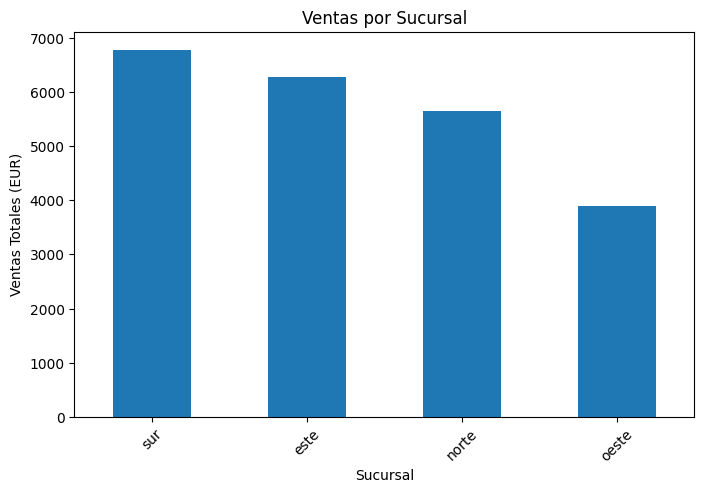

In [17]:
plt.figure(figsize=(8,5))
ventas_sucursal.plot(kind='bar')
plt.title('Ventas por Sucursal')
plt.xlabel('Sucursal')
plt.ylabel('Ventas Totales (EUR)')
plt.xticks(rotation=45)
plt.show()

**--La sucursal ESTE es la sucursal que mas vende en ventas totales--**

In [18]:
visitas_sucursal = df.groupby('sucursal')['id_venta'].count().sort_values(ascending=False)
visitas_sucursal

sucursal
sur      13
norte    10
este      9
oeste     8
Name: id_venta, dtype: int64

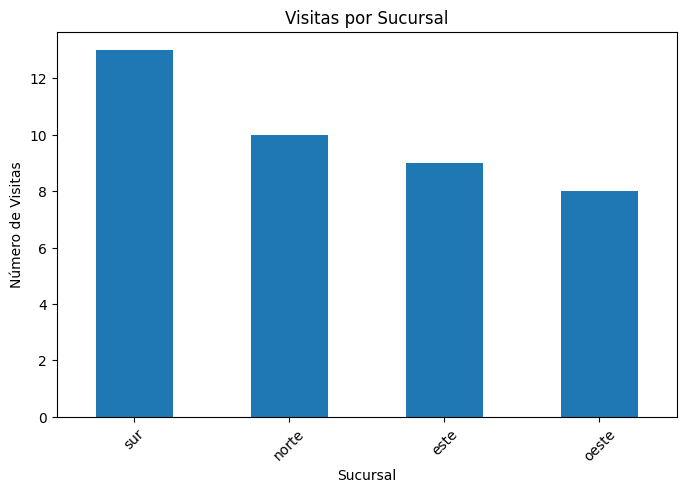

In [19]:
plt.figure(figsize=(8,5))
visitas_sucursal.plot(kind='bar')
plt.title('Visitas por Sucursal')
plt.xlabel('Sucursal')
plt.ylabel('Número de Visitas')
plt.xticks(rotation=45)
plt.show()

**--La sucursal sur es la mas popular, con mas visitas--**

In [20]:
ventas_categoria = df.groupby('categoria')['importe_total'].sum().sort_values(ascending=False)
ventas_categoria

categoria
perfumeria    7170
joyeria       6130
caballeros    3440
damas         3400
calzado       2440
Name: importe_total, dtype: int64

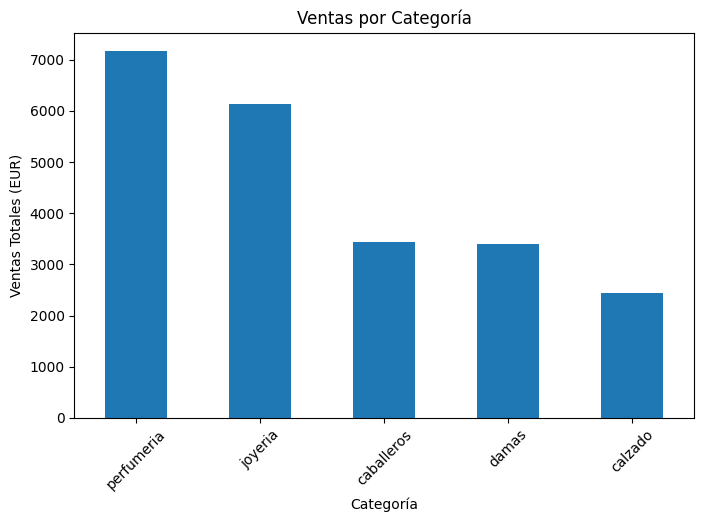

In [21]:
plt.figure(figsize=(8,5))
ventas_categoria.plot(kind='bar')
plt.title('Ventas por Categoría')
plt.xlabel('Categoría')
plt.ylabel('Ventas Totales (EUR)')
plt.xticks(rotation=45)
plt.show()

**--La categoria mas rentable es PERFUMERÍA--**

## Tendencia de ventas por mes

In [22]:
ventas_mes = df.groupby('mes')['importe_total'].sum().reindex(['February', 'March', 'April', 'May', 'June'])
ventas_mes

mes
February     240
March       8220
April       6240
May         2490
June        5390
Name: importe_total, dtype: int64

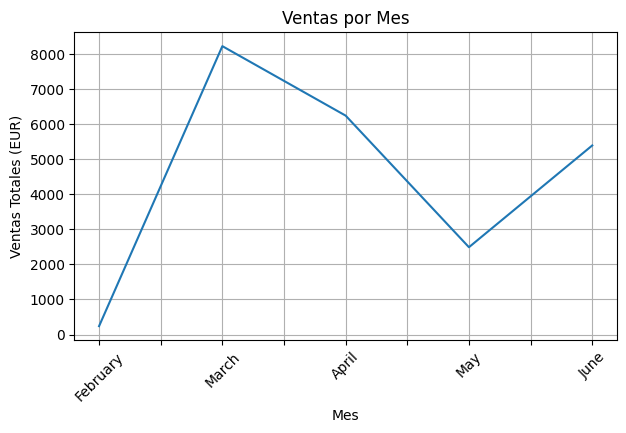

In [23]:
plt.figure(figsize=(7,4))
ventas_mes.plot(kind='line')
plt.title('Ventas por Mes')
plt.xlabel('Mes')
plt.ylabel('Ventas Totales (EUR)')
plt.xticks(rotation=45)
plt.grid()
plt.show()

## Tendencia de ventas por fecha 

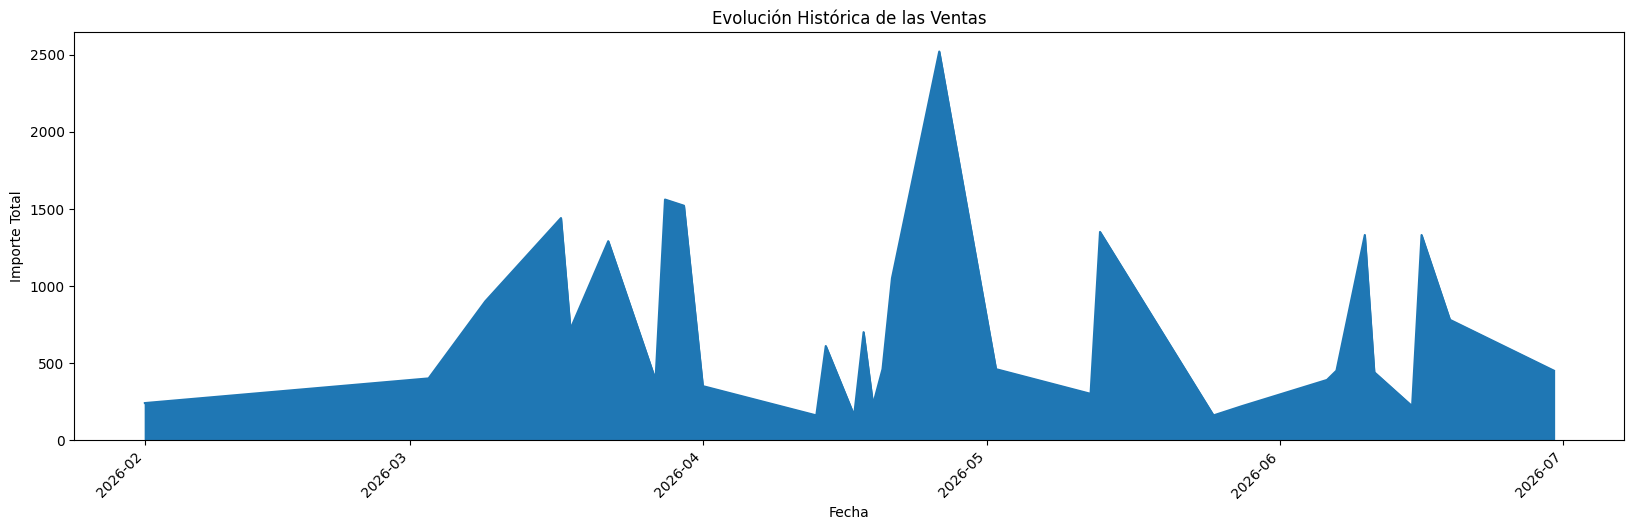

fecha
2026-02-01     240
2026-03-03     400
2026-03-09     900
2026-03-17    1440
2026-03-18     720
2026-03-22    1290
2026-03-27     390
2026-03-28    1560
2026-03-30    1520
2026-04-01     350
2026-04-13     160
2026-04-14     610
2026-04-17     160
2026-04-18     700
2026-04-19     230
2026-04-20     460
2026-04-21    1050
2026-04-26    2520
2026-05-02     460
2026-05-12     300
2026-05-13    1350
2026-05-25     160
2026-05-28     220
2026-06-06     390
2026-06-07     450
2026-06-10    1330
2026-06-11     440
2026-06-15     220
2026-06-16    1330
2026-06-19     780
2026-06-30     450
Name: importe_total, dtype: int64

In [24]:
# Convertir fecha a datetime si no lo es
df['fecha'] = pd.to_datetime(df['fecha'])

# Agrupar por fecha y sumar importe_total
ventas_por_fecha = df.groupby('fecha')['importe_total'].sum().sort_index()

# Graficar
plt.figure(figsize=(20,6))
ventas_por_fecha.plot(kind='area')
plt.title('Evolución Histórica de las Ventas')
plt.xlabel('Fecha')
plt.ylabel('Importe Total')
plt.xticks(rotation=45)
plt.show()

ventas_por_fecha


Las cuatro preguntas se han resuelto

- ¿Que producto genera mas ingresos?
  - EL producto que mas vende es la **LOCION**
- ¿Que sucursal vende mas?
  - la sucursal que mas vende es la sucursal **ESTE**
  - la sucursal mas popular es la sucursal **SUR**
- ¿Que categoría es la mas rentable?
  - la categoría mas rentable es la **PERFUMERIA**
- ¿Que tendencias hay por mes?
  - ver último gráfico